In [1]:
!pip install transformers torch torchvision matplotlib seaborn

In [2]:
import torch
import torch.nn.functional as F
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import numpy as np

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load the CLIP model and processor used in your notebook
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

print(f"✅ CLIP model loaded on {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

✅ CLIP model loaded on cpu


In [3]:
print("Upload 2 or more images to compare:")
uploaded = files.upload()
image_paths = list(uploaded.keys())

# Load and convert images to RGB
images = [Image.open(path).convert("RGB") for path in image_paths]

Upload 2 or more images to compare:


Saving Screenshot 2026-02-13 131609.png to Screenshot 2026-02-13 131609.png
Saving Screenshot 2026-02-13 131642.png to Screenshot 2026-02-13 131642.png


In [6]:
# Extract features
inputs = processor(images=images, return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    # The 'image_features' variable currently holds a BaseModelOutputWithPooling object.
    # We need to access its 'pooler_output' attribute to get the actual image feature tensor.
    image_features = model.get_image_features(**inputs).pooler_output

# Normalize features
image_features = image_features / image_features.norm(p=2, dim=-1, keepdim=True)

# Compute Similarity Matrix (All-to-All)
# This uses the formula: (A . B) / (||A|| * ||B||) which is simplified for normalized vectors
similarity_matrix = torch.mm(image_features, image_features.transpose(0, 1)).cpu().numpy()

# Print Scores
print("\n--- Cosine Similarity Scores ---")
for i in range(len(image_paths)):
    for j in range(i + 1, len(image_paths)):
        print(f"Similarity between {image_paths[i]} and {image_paths[j]}: {similarity_matrix[i][j]:.4f}")


--- Cosine Similarity Scores ---
Similarity between Screenshot 2026-02-13 131609.png and Screenshot 2026-02-13 131642.png: 0.9335


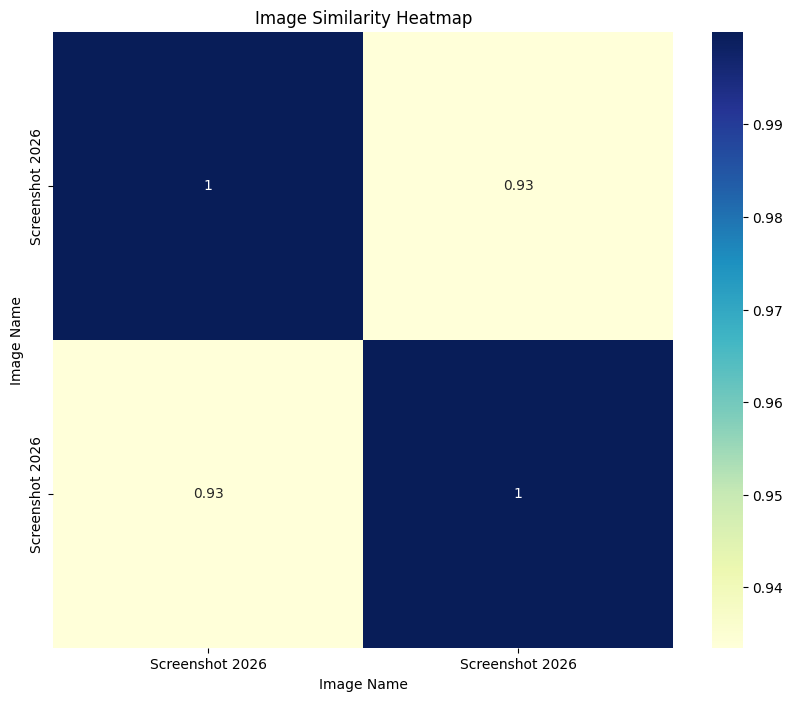

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, cmap="YlGnBu",
            xticklabels=[p[:15] for p in image_paths],
            yticklabels=[p[:15] for p in image_paths])
plt.title("Image Similarity Heatmap")
plt.xlabel("Image Name")
plt.ylabel("Image Name")
plt.show()